In [2]:
import json

# Replace 'experiment_data.json' with the path to your JSON file
with open('../data_experiment/data12/experiment_data.json', 'r') as file:
    data = json.load(file)

6210


C:\Users\ajayc\AppData\Local\Temp\ipykernel_1216\108994414.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(precision_by_k, labels=range(1, 11))


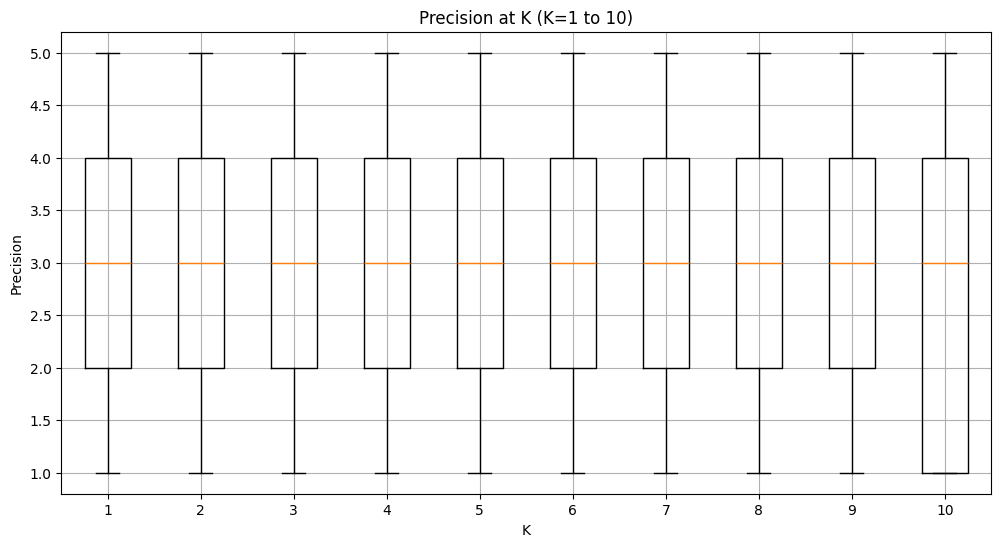

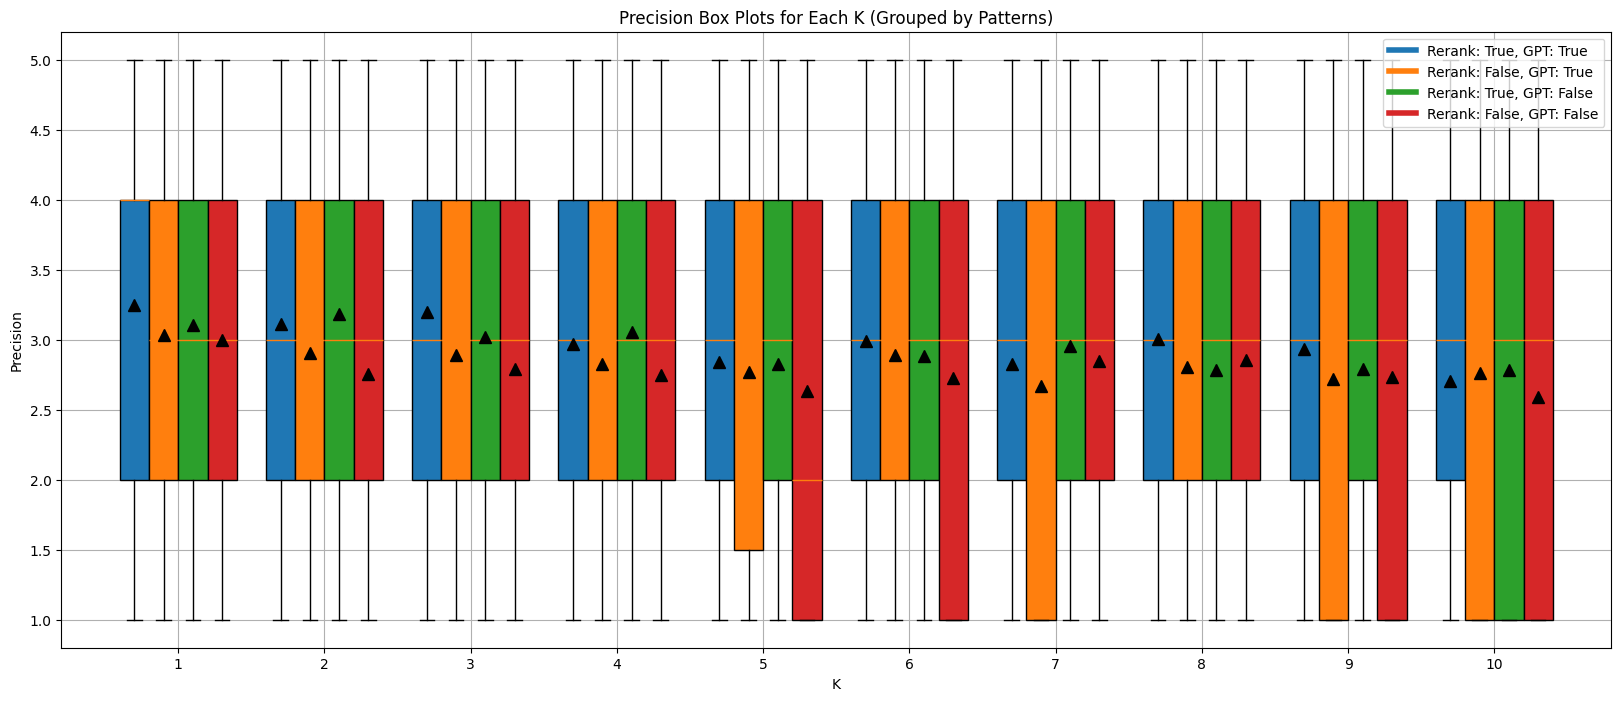

In [9]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Function to calculate precision at k
def calculate_precision(ratings):
    precisions = []
    relevant_count = 0
    
    for k, rating in enumerate(ratings, start=1):
        if int(rating) >= 3:  # Consider rating >= 3 as relevant
            relevant_count += 1
        precisions.append(relevant_count / k)
    
    return precisions

# Extract and calculate precision data
precision_data = []
for student_id, student in data.get("student_data", {}).items():
    for task in student.get("tasks", []):
        task_name = task.get("taskName")
        rerank_engine = task.get("rerank_engine", False)
        gpt = task.get("gpt", False)
        
        for question_key, solutions in task.get("solutions", {}).items():
            for solution in solutions:
                # if(gpt==True and not '?' in solution.get("searchQuery")):
                #     print(student_id,task_name,question_key,solution.get("searchQuery"), gpt)
                
                ratings = [int(issue['rating']) for issue in solution.get("ratings", [])]
                
                precisions = calculate_precision(ratings)
                
                for k, precision in enumerate(ratings, start=1):
                    # print(student_id, task_name, question_key, rerank_engine, gpt, k, precision)
                    precision_data.append({
                        "Student ID": student_id,
                        "Task Name": task_name,
                        "Question Key": question_key,
                        "Rerank Engine": rerank_engine,
                        "GPT": gpt,
                        "K": k,
                        "Precision": precision
                    })

# Convert to DataFrame
print(len(precision_data))
df = pd.DataFrame(precision_data)

# Generate box plots for precision at each k
precision_by_k = [group['Precision'].values for _, group in df.groupby('K')]
plt.figure(figsize=(12, 6))
# for i in range(10):
    # Calculate quartiles and IQR
    # q1 = np.percentile(precision_by_k[i], 25)
    # q2 = np.percentile(precision_by_k[i], 50)
    # q3 = np.percentile(precision_by_k[i], 75)
    # iqr = q3 - q1
    # # Calculate upper and lower bounds for outliers
    # lower_bound = q1 - 1.5 * iqr
    # upper_bound = q3 + 1.5 * iqr
    # filtered_data = [val for val in precision_by_k[i] if lower_bound <= val <= upper_bound]
    # precision_by_k[i] = filtered_data
    # print(precision_by_k[i])


# print(precision_by_k[0])
plt.boxplot(precision_by_k, labels=range(1, 11))
plt.title('Precision at K (K=1 to 10)')
plt.xlabel('K')
plt.ylabel('Precision')
plt.grid(True)
plt.show()


# # Define combinations of rerank_engine and gpt
patterns = [
    {"Rerank Engine": True, "GPT": True},
    {"Rerank Engine": False, "GPT": True},
    {"Rerank Engine": True, "GPT": False},
    {"Rerank Engine": False, "GPT": False},
]

# Group data by K and patterns, prepare for box plots
plot_data = {k: [] for k in range(1, 11)}
pattern_labels = []

for pattern in patterns:
    pattern_label = f'Rerank: {pattern["Rerank Engine"]}, GPT: {pattern["GPT"]}'
    pattern_labels.append(pattern_label)
    
    # Filter data for the current pattern
    filtered_df = df[(df["Rerank Engine"] == pattern["Rerank Engine"]) & (df["GPT"] == pattern["GPT"])]
    
    # Group by K and collect precision values
    for k, group in filtered_df.groupby('K'):
        plot_data[k].append(group['Precision'].values)

# Create the plot
plt.figure(figsize=(20, 8))

# Prepare box plots for each K
positions = np.arange(1, 11)  # Base positions for each K
width = 0.2  # Space between box plots for different patterns

for i, pattern_label in enumerate(pattern_labels):
    offset = i * width  # Offset for each pattern
    current_positions = positions + offset
    P_data = [plot_data[k][i] for k in range(1, 11)]
    plt.boxplot(P_data, positions=current_positions, widths=width,showmeans=True, showfliers=False, patch_artist=True, 
                boxprops=dict(facecolor=f"C{i}"),meanprops=dict( markerfacecolor='black', markeredgecolor='black', markersize=8))  # Colorize each pattern differently

# Customize the plot
plt.xticks(positions + width * 1.5, labels=range(1, 11))  # Center labels for each K
plt.title("Precision Box Plots for Each K (Grouped by Patterns)")
plt.xlabel("K")
plt.ylabel("Precision")
# plt.legend(
#     handles=[
#         plt.Line2D([0], [0], color=f"C{i}", lw=6, label=pattern_label, linestyle='-', marker='o', markersize=10, markerfacecolor='black')
#         if "Median" in pattern_label else plt.Line2D([0], [0], color=f"C{i}", lw=4, label=pattern_label)
#         for i, pattern_label in enumerate(pattern_labels)
#     ],
#     loc='upper right'
# )
plt.legend(handles=[plt.Line2D([0], [0], color=f"C{i}", lw=4, label=pattern_label) 
                    for i, pattern_label in enumerate(pattern_labels)], loc='upper right')
plt.grid(True)
plt.show()